# 基本 Matplotlib 設定：先把畫布準備好，資料才說得清楚

## Matplotlib 是什麼？

Matplotlib 是 Python 常用的繪圖工具。可以把它想成「用程式控制的畫圖軟體」：

- 資料是要表達的內容，例如每天花多少錢。
- 圖形是表達方式，例如折線、長條或圓點。
- 設定是溝通品質，例如標題夠不夠清楚、中文字會不會變方框。

## 尚未安裝套件怎麼辦？

若下一格出現 `ModuleNotFoundError`，可在 Notebook 新增一格並執行：

```python
%pip add matplotlib numpy # IPython pip magic
!pip add matplotlib numpy # 呼叫 Shell 執行 pip
```

`%pip` 會把套件安裝到目前 Notebook 使用的 Python 環境。安裝後若仍無法匯入，請重新啟動 Kernel，再從頭執行。已能正常匯入的電腦不必重複安裝。


In [2]:
# 匯入繪圖工具並確認版本
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

print(f"Matplotlib 版本：{matplotlib.__version__}")
print(f"NumPy 版本：{np.__version__}")


Matplotlib 版本：3.11.2
NumPy 版本：2.5.2


### 全域設定與單張設定

`plt.rcParams` 像「整間教室的共同規則」，設定後，之後建立的圖都會受到影響。`ax.set_title(...)` 則像「只對這一位同學的要求」，只改目前這張圖。

| 範圍 | 寫法示例 | 適合情況 |
|---|---|---|
| 全域 | `plt.rcParams["font.size"] = 12` | 整份 Notebook 統一字體大小 |
| 單張 | `ax.set_title(..., fontsize=16)` | 某一張圖需要特別突出 |

### 設定中文字型

In [3]:
plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常

## 圖表的骨架：Figure 與 Axes

這是初學者最容易混淆、卻最值得理解的地方。

- **Figure（整張畫布）**：像一張白色海報紙，可以裝一個或多個圖表。
- **Axes（單一繪圖區）**：像海報紙上畫出的區塊，真正的折線、標題、刻度都放在這裡。
- **Axis（座標軸）**：Axes 裡面的 x 軸或 y 軸。注意 `Axes` 與 `Axis` 拼字相近但意思不同。

```
Figure（整張紙）
└── Axes（其中一個圖表區）
    ├── x-axis（水平座標軸）
    ├── y-axis（垂直座標軸）
    ├── title（標題）
    └── plot / bar / scatter（資料圖形）
```

`plt.subplots()` 會一次交給我們兩樣東西：

```python
fig, ax = plt.subplots()
```

左邊的 `fig` 接住整張畫布，`ax` 接住一個繪圖區。這種寫法叫做 **物件導向介面**，後續複雜圖表較容易控制，也是本教材主要採用的方式。


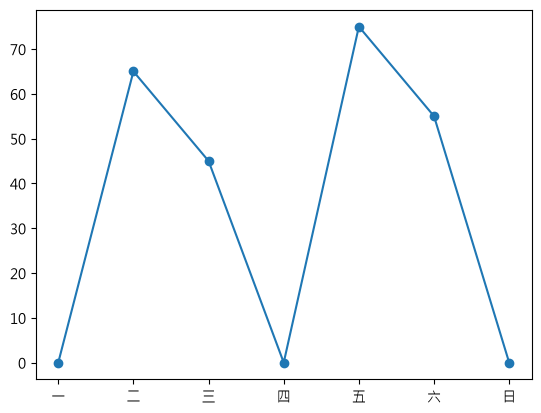

In [4]:
# 範例：手搖飲一週花費（先畫出最小可用圖表）
import matplotlib.pyplot as plt

### 建立資料
days = ["一", "二", "三", "四", "五", "六", "日"]  # X 軸：星期
drink_cost = [0, 65, 45, 0, 75, 55, 0]          # Y 軸：每天飲料花費

### 建立 Figure 與 Axes
fig, ax = plt.subplots()  # fig 是整張畫布，ax 是實際繪圖的區域

### 繪製折線圖
ax.plot(
    days,                 # X 軸資料
    drink_cost,           # Y 軸資料
    marker="o"            # 在每筆資料的位置加上圓形標記
)

plt.show() ### 顯示圖表

## 畫布大小與解析度：`figsize`、`dpi` 到底是什麼？

`figsize=(寬, 高)` 的單位是 **英吋**，不是像素。`dpi` 是每英吋有多少個點。因此：

> 圖片像素寬度 = 英吋寬度 × dpi

例如 `figsize=(8, 4), dpi=100`，顯示時約為 800 × 400 像素。

- 報告內嵌圖常用 `(8, 4.5)`。
- 投影片通常要寬一些，例如 `(12, 6.75)`，接近 16:9。
- `dpi=100` 適合螢幕預覽；存檔 `dpi=150~300` 通常更清楚。
- dpi 越高，檔案通常越大；不是無限提高就一定更好。


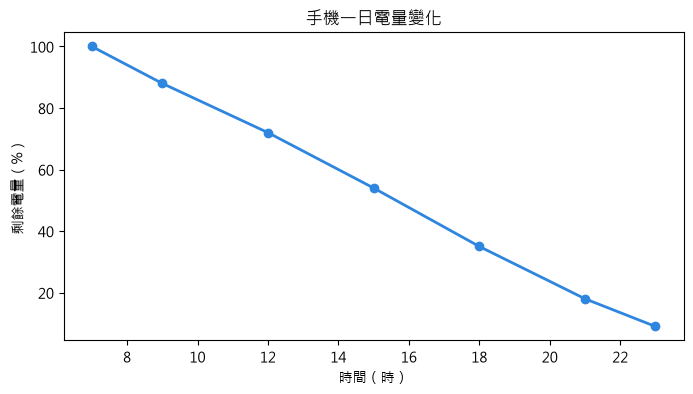

In [5]:
# 範例：手機從早上到晚上的電量變化
hours = [7, 9, 12, 15, 18, 21, 23]
battery = [100, 88, 72, 54, 35, 18, 9]

fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
ax.plot(hours, battery, color="#2E86DE", marker="o", linewidth=2)
ax.set_title("手機一日電量變化")
ax.set_xlabel("時間（時）")
ax.set_ylabel("剩餘電量（%）")
plt.show()


## 樣式 Style：快速換一組外觀

Matplotlib 的 style 是一組預先配好的視覺設定，包括背景、格線、顏色與字體大小。它像手機相機的濾鏡，但資料本身不會改變。

可以先列出環境中可用的樣式。不同版本的清單可能略有差異，因此正式教材不要假設每台電腦都有某個第三方樣式。


In [6]:
print("目前可用樣式（前 15 個）：")
print(plt.style.available[:15])

目前可用樣式（前 15 個）：
['Solarize_Light2', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'petroff6', 'petroff8', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark']


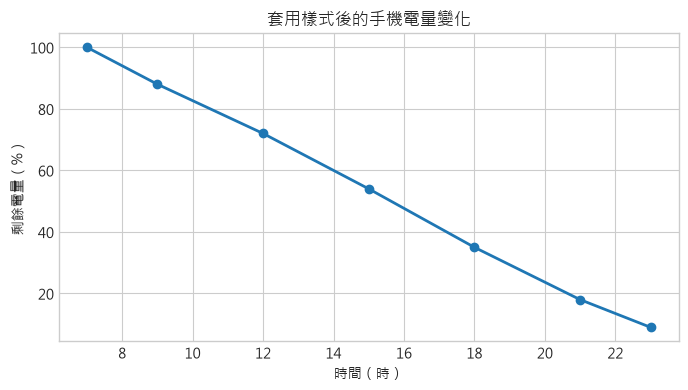

In [7]:
# 用 style context 只暫時改這一張，離開區塊後不污染其他圖
with plt.style.context("seaborn-v0_8-whitegrid"):
    # 中文設定
    plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
    plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(hours, battery, marker="o", linewidth=2)
    ax.set_title("套用樣式後的手機電量變化")
    ax.set_xlabel("時間（時）")
    ax.set_ylabel("剩餘電量（%）")
    plt.show()

### 標題、軸標籤與單位：不要讓觀眾猜

只寫「比較」通常不夠。一個合格標題至少要讓人知道「比較什麼」，必要時補上時間、地點或對象。

- 模糊：`通勤比較`
- 清楚：`不同交通方式的單程通勤時間`

座標軸也要寫單位。「35」究竟是 35 分鐘、35 元還是 35 公里？少一個單位，圖就可能被誤讀。


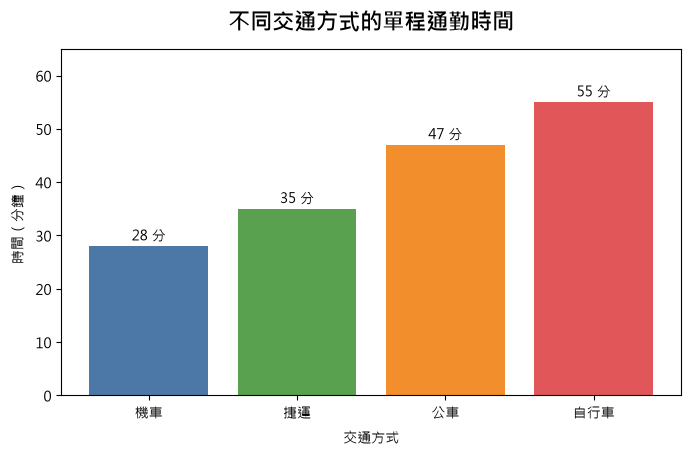

In [8]:
# 範例 3：通勤時間比較
transport = ["機車", "捷運", "公車", "自行車"]
minutes = [28, 35, 47, 55]
colors = ["#4C78A8", "#59A14F", "#F28E2B", "#E15759"]

with plt.style.context("default"):
    # 中文設定
    plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
    plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(transport, minutes, color=colors)
    ax.set_title("不同交通方式的單程通勤時間", fontsize=16, fontweight="bold", pad=14)
    ax.set_xlabel("交通方式", labelpad=8)
    ax.set_ylabel("時間（分鐘）", labelpad=8)
    ax.set_ylim(0, 65)
    ax.bar_label(bars, labels=[f"{m} 分" for m in minutes], padding=3)
    plt.show()


### 關鍵參數拆解

- `fontsize=16`：字級。
- `fontweight="bold"`：粗體。
- `pad=14`：標題與繪圖區的距離。
- `labelpad=8`：軸標籤與座標軸的距離。
- `set_ylim(0, 65)`：設定 y 軸顯示範圍。
- `bar_label(...)`：把精確數值標在長條旁。

長條圖通常應從 0 開始，因為長條「長度」代表數量。如果偷偷從 25 開始，28 與 55 的差距在畫面上會被誇大。這不只是美術問題，也涉及資料倫理。


## 刻度、格線、圖例與註解：幫眼睛找到重點

- 刻度 ticks：刻度是尺上的刻痕。太密會擁擠，太少則難以估讀。`set_xticks()`、`set_yticks()` 可以明確指定位置與文字。
- 格線 grid：格線像尺的延伸，幫助視線從資料點對到刻度。通常只保留需要的方向，並用 `alpha` 降低存在感。
- 圖例 legend：同一張圖有多組資料時，圖例負責說明顏色或線條代表誰。要先在繪圖指令加 `label=`，再呼叫 `legend()`。
- 註解 annotate：註解用來指出轉折、最高點或事件，不應每個點都加到滿。


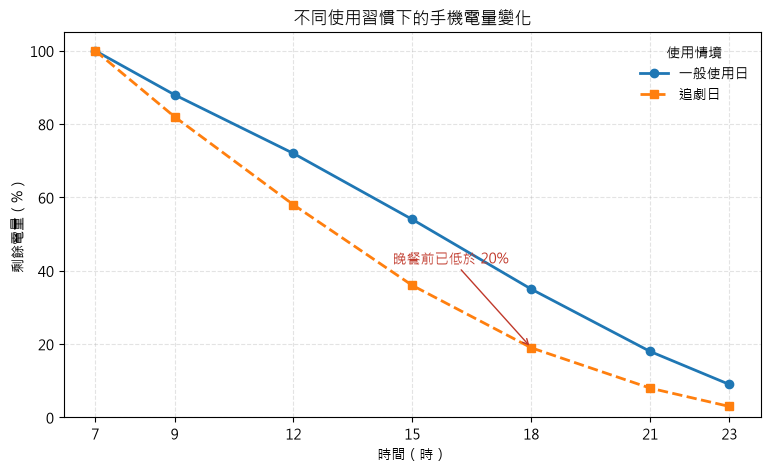

In [9]:
# 範例 2 延伸：比較一般使用日與追劇日的手機電量
normal_day = [100, 88, 72, 54, 35, 18, 9]
binge_day = [100, 82, 58, 36, 19, 8, 3]

with plt.style.context("default"):
    # 中文設定
    plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
    plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(hours, normal_day, marker="o", linewidth=2, label="一般使用日")
    ax.plot(hours, binge_day, marker="s", linewidth=2, linestyle="--", label="追劇日")
    ax.set_title("不同使用習慣下的手機電量變化")
    ax.set_xlabel("時間（時）")
    ax.set_ylabel("剩餘電量（%）")
    ax.set_xticks(hours)
    ax.set_yticks(range(0, 101, 20))
    ax.set_ylim(0, 105) # 設定 Y 軸顯示範圍：最小0、最大105
    ax.grid(axis="both", linestyle="--", alpha=0.35)
    ax.legend(title="使用情境", frameon=False)

    # xy 是箭頭指向的資料位置，xytext 是說明文字所在位置
    ax.annotate(
        "晚餐前已低於 20%",
        xy=(18, 19), xytext=(14.5, 42),
        arrowprops={"arrowstyle": "->", "color": "#C0392B"},
        color="#C0392B"
    )
    plt.show()


### `alpha` 是什麼？

`alpha` 控制透明度，範圍是 0 到 1：

- `alpha=0`：完全透明，看不見。
- `alpha=0.3`：淡淡的。
- `alpha=1`：完全不透明。

格線常用 0.2～0.4，因為它的工作是協助閱讀，不是成為主角。


## 顏色與可讀性：不只「我喜歡藍色」

顏色常見有三種用途：

1. **分類**：餐費、交通、娛樂用不同顏色。
2. **強調**：大部分用灰色，只把異常值用紅色。
3. **表示高低**：由淺到深代表數值大小。

常見寫法：名稱如 `"steelblue"`、十六進位色碼如 `"#2E86DE"`、RGB 比例。教學與工作中，十六進位色碼容易精準重複。

不要只靠紅綠區分資訊。部分觀眾難以分辨紅綠，也可能在黑白列印時失去差異。可以同時使用不同線型、標記或文字標籤。


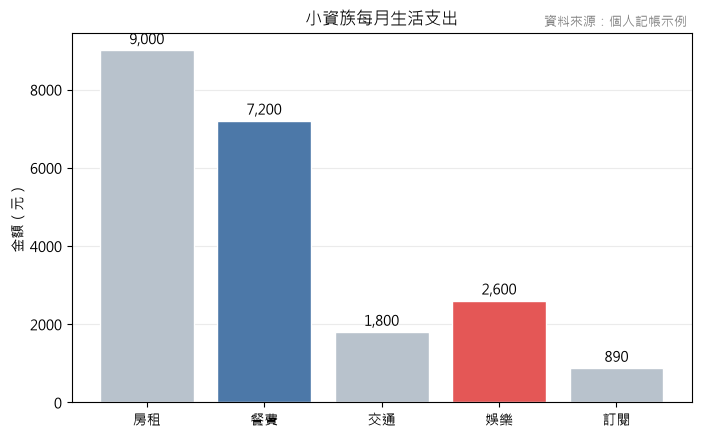

In [10]:
# 範例 4：每月生活支出；用一個強調色指出最可調整的項目
categories = ["房租", "餐費", "交通", "娛樂", "訂閱"]
expenses = [9000, 7200, 1800, 2600, 890]
bar_colors = ["#B8C2CC", "#4C78A8", "#B8C2CC", "#E45756", "#B8C2CC"]

with plt.style.context("default"):
    # 中文設定
    plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
    plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
    fig, ax = plt.subplots(figsize=(8, 4.8))
    bars = ax.bar(categories, expenses, color=bar_colors, edgecolor="white")
    ax.set_title("小資族每月生活支出")
    ax.set_ylabel("金額（元）")
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)  # 讓格線畫在長條後面
    ax.bar_label(bars, labels=[f"{v:,}" for v in expenses], padding=3)
    ax.text(4.6, 9630, "資料來源：個人記帳示例",  ha="right",  fontsize=9, color="gray")
    plt.show()


## 邊框與留白：資訊少一點，重點反而更多

繪圖區四周的線叫做 `spines`。不是每張圖都需要完整方框。移除上、右邊框常能讓商業圖表更清爽。

文字被切掉則多半是版面空間不足：

- 建立畫布時使用 `layout="constrained"`，讓 Matplotlib 自動協調元件。
- 或畫完後使用 `fig.tight_layout()`。
- 存檔時加 `bbox_inches="tight"`，裁切多餘白邊並保留文字。

同一張圖通常選一種主要自動排版策略即可，不必全部混用。


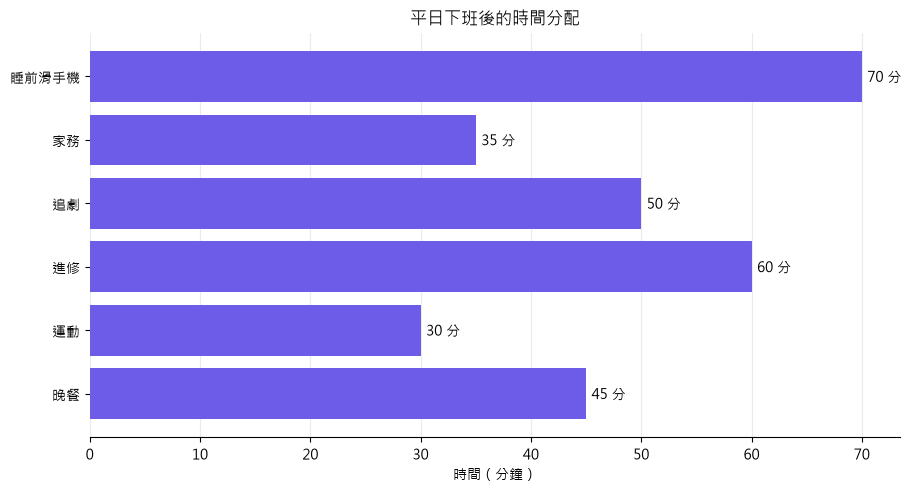

In [11]:
# 範例：下班後可用時間
activities = ["晚餐", "運動", "進修", "追劇", "家務", "睡前滑手機"]
time_minutes = [45, 30, 60, 50, 35, 70]

with plt.style.context("default"):
    # 中文設定
    plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
    plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
    fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained") # 建立 9 × 4.8 英吋的圖表，並自動調整版面避免文字被裁切
    bars = ax.barh(activities, time_minutes, color="#6C5CE7") ### 建立水平長條圖
    ax.set_title("平日下班後的時間分配")
    ax.set_xlabel("時間（分鐘）") 
    ax.grid(axis="x", alpha=0.25) ### 設定格線：只顯示 X 軸方向的格線，alpha 設定透明度
    ax.set_axisbelow(True) # 將格線放到長條圖後方，避免格線蓋住長條
    ax.spines[["top", "right", "left"]].set_visible(False) # 隱藏部分邊框：隱藏上方、右方與左方的圖表邊框
    ax.bar_label(bars, labels=[f"{v} 分" for v in time_minutes], padding=4)
    plt.show()

## 一張畫布放多張圖：subplots

當問題需要同時看「花了多少錢」與「花了多少時間」，可以把兩張相關圖放在同一張 Figure。`plt.subplots(1, 2)` 表示 1 列 2 欄。

回傳的 `axes` 是一組 Axes，像兩個編號座位：`axes[0]` 是左圖、`axes[1]` 是右圖。若是 2 列 2 欄，就會更像表格，可用 `axes[列, 欄]` 取得位置。


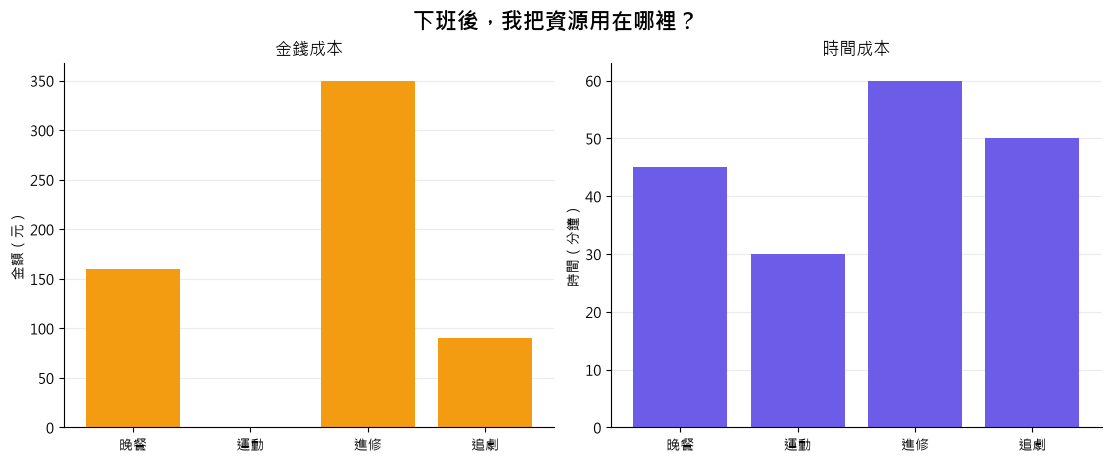

In [12]:
# 同時比較下班後的金錢與時間使用
activities_short = ["晚餐", "運動", "進修", "追劇"]
costs = [160, 0, 350, 90]
minutes = [45, 30, 60, 50]

with plt.style.context("default"):
    # 中文設定
    plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
    plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常
    
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), layout="constrained")
    fig.suptitle("下班後，我把資源用在哪裡？", fontsize=16, fontweight="bold")
    ### 第一章圖
    axes[0].bar(activities_short, costs, color="#F39C12")
    axes[0].set_title("金錢成本")
    axes[0].set_ylabel("金額（元）")
    ### 第二章圖
    axes[1].bar(activities_short, minutes, color="#6C5CE7")
    axes[1].set_title("時間成本")
    axes[1].set_ylabel("時間（分鐘）")

    for ax in axes:
        ax.grid(axis="y", alpha=0.25)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)

    plt.show()


## 輸出圖片：讓成果能放進報告與履歷

Notebook 裡看得到不代表檔案已經保存。`fig.savefig()` 才會把 Figure 寫成檔案。

常見格式：

- PNG：點陣圖，適合網頁、簡報、一般報告。
- SVG：向量圖，放大仍清楚，適合網頁或後續編輯。
- PDF：適合列印與文件交換。

建議使用 `fig.savefig(...)`，因為它清楚指定要儲存哪一張 Figure。通常先儲存再 `plt.show()`，可以避免某些環境在顯示後清空目前圖形。


已輸出：..\Data_Visualization_output\通勤時間比較.png
已輸出：..\Data_Visualization_output\通勤時間比較.svg


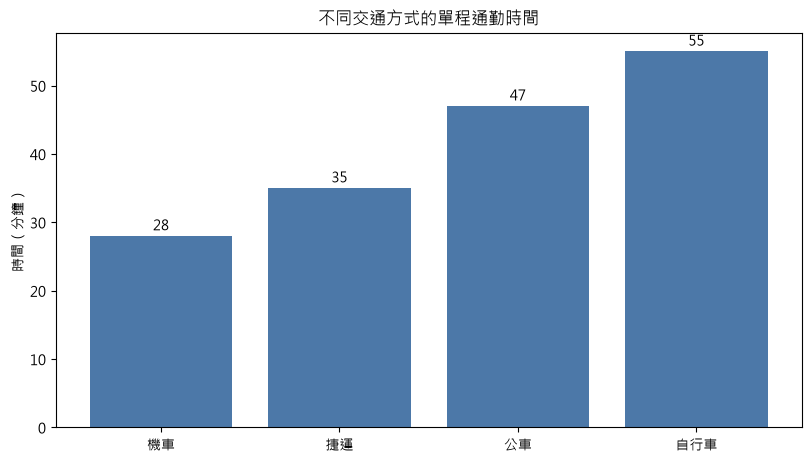

In [13]:
### 設定輸出資料夾
output_dir = Path("../Data_Visualization_output")

with plt.style.context("default"):
    # 中文設定
    plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
    plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常

    fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
    bars = ax.bar(transport, [28, 35, 47, 55], color="#4C78A8")
    ax.set_title("不同交通方式的單程通勤時間")
    ax.set_ylabel("時間（分鐘）")
    ax.bar_label(bars, padding=3)

    ### 設定輸出路徑
    png_path = output_dir / "通勤時間比較.png"
    svg_path = output_dir / "通勤時間比較.svg"

    fig.savefig(png_path, dpi=200, bbox_inches="tight", facecolor="white")
    fig.savefig(svg_path, bbox_inches="tight", facecolor="white")
    # facecolor="white"：指定白色背景，避免某些軟體顯示透明背景時變黑。
    # bbox_inches="tight：盡量保留文字並裁掉過多白邊。
    print(f"已輸出：{png_path}")
    print(f"已輸出：{svg_path}")
    plt.show()


## 建立自己的統一設定

當公司報表有 30 張圖，不應每張都重複設定中文字型、尺寸與格線。可以把常用規則集中管理。`rcParams.update()` 會更新全域設定，適合在 Notebook 開頭執行一次。


In [14]:
import matplotlib.pyplot as plt


### 建立通用 Matplotlib 設定
default_style = {
    # 圖表大小與解析度
    "figure.figsize": (8, 4.5),
    "figure.dpi": 100,
    "savefig.dpi": 200,

    # 中文與負號
    "font.family": "Microsoft JhengHei",
    "axes.unicode_minus": False,

    # 文字大小
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,

    # 標題
    "axes.titleweight": "bold",

    # 圖表外觀
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,

    # 線條
    "lines.linewidth": 2,
    "lines.markersize": 6,

    # 圖例
    "legend.frameon": False,

    # 儲存圖片
    "savefig.bbox": "tight",
    "savefig.facecolor": "white"
}


### 套用通用設定
plt.rcParams.update(default_style)

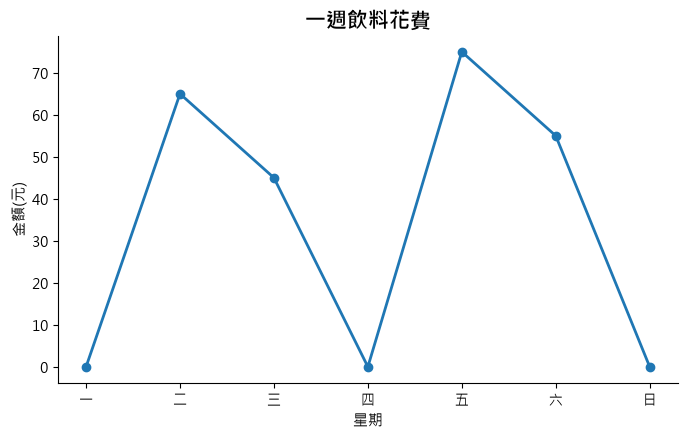

In [18]:

### 準備資料
days = ["一", "二", "三", "四", "五", "六", "日"]
drink_cost = [0, 65, 45, 0, 75, 55, 0]

plt.rcParams.update(default_style) ### 套用通用設定
fig, ax = plt.subplots() ### 建立圖表
ax.plot(days, drink_cost, marker="o")
ax.set_title("一週飲料花費")
ax.set_xlabel("星期")
ax.set_ylabel("金額(元)")
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv("./Data_Visualization_data/早餐店交易.csv")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

with sns.axes_style("whitegrid"): # 套用 Seaborn 樣式
	# 中文設定
	plt.rcParams["font.family"] = "Microsoft JhengHei" # Windows 微軟正黑體
	plt.rcParams["axes.unicode_minus"] = False # 避免負號顯示異常